<a href="https://colab.research.google.com/github/gencere757/ARDA-GENCER-DSA210-TERM-PROJECT/blob/main/DSA210_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Filtering, Cleaning And Transforming The Data
Importing the necessary libraries

In [19]:
import pandas as pd
import numpy as np

### 1.1 Heart Disease Mortality Rate Data
  Here, the heart disease mortality rate data were made into a dataframe, the empty or NaN values were cleared, and a seperate column for log values were added since they will be needed to apply log transform when plotting later.

In [50]:
hdDF = pd.read_csv('Heart_Disease_Mortality_Data_Among_US_Adults__35___by_State_Territory_and_County___2019-2021.csv')
hdDF = hdDF[hdDF['GeographicLevel'] == "County"]  #Clean non county rows
hdDF_cleaned = hdDF.dropna(subset=['Data_Value']).copy()  #Clean empty values
hdDF_cleaned['Log_Mortality'] = np.log1p(hdDF_cleaned['Data_Value'])  #Create new column with log transformed values
hdDF_cleaned

,Year,LocationAbbr,LocationDesc,GeographicLevel,DataSource,Class,Topic,Data_Value,Data_Value_Unit,Data_Value_Type,...,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,TopicID,LocationID,Y_lat,X_lon,Georeference,Log_Mortality
0,2020,AK,Denali,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,348.8,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Male,Race/Ethnicity,White,T2,2068,63.678820,-149.960801,POINT (-149.9608012 63.67881971),5.857362
2,2020,CO,Park County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,135.9,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Female,Race/Ethnicity,White,T2,8093,39.115616,-105.708698,POINT (-105.7086982 39.11561621),4.919251
3,2020,FL,Walton County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,126.5,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Female,Race/Ethnicity,Asian,T2,12131,30.655966,-86.157457,POINT (-86.15745736 30.65596581),4.848116
4,2020,GA,Whitfield County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,155.1,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Female,Race/Ethnicity,Hispanic,T2,13313,34.803854,-84.962112,POINT (-84.96211184 34.80385386),5.050497
6,2020,IA,Ida County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,168.0,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Overall,Race/Ethnicity,Hispanic,T2,19093,42.387689,-95.523143,POINT (-95.52314316 42.38768939),5.129899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78784,2020,VA,Prince William County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,228.4,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Overall,Race/Ethnicity,White,T2,51153,38.704617,-77.481441,POINT (-77.48144058 38.70461706),5.435467
78786,2020,WI,Menominee County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,451.7,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Male,Race/Ethnicity,White,T2,55078,45.005150,-88.704268,POINT (-88.70426767 45.00514971),6.115230
78788,2020,WA,San Juan County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,307.7,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Male,Race/Ethnicity,Asian,T2,53055,48.535986,-123.082448,POINT (-123.0824477 48.53598644),5.732370
78789,2020,WA,Pierce County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,297.2,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Sex,Female,Race/Ethnicity,American Indian or Alaska Native,T2,53053,47.016724,-122.091967,POINT (-122.0919668 47.01672374),5.697764


### 1.2 The Walkabiltiy Index Data
Here, the walkability index data was extracted from its .csv file.

In [22]:
walkDF = pd.read_csv('WalkabilityIndexByCounty.csv')
walkDF

,Unnamed: 0,GEOID10,NatWalkInd,County
0,1,1001,5.234375,Autauga
1,2,1003,6.450355,Baldwin
2,3,1005,5.188406,Barbour
3,4,1007,5.033333,Bibb
4,5,1009,4.666667,Blount
...,...,...,...,...
1897,3607,72139,4.865079,Trujillo Alto
1898,3609,72143,4.015152,Vega Alta
1899,3611,72145,4.450450,Vega Baja
1900,3614,72149,3.254902,Villalba


In [41]:
foodDF = pd.read_csv('StateAndCountyData.csv')
restaurantDF = foodDF[foodDF['Variable_Code'] == "FFRPTH20"]   #Fast food restaurants per 1000 people in county
restaurantDF = restaurantDF[restaurantDF['Value']>0].copy()
restaurantDF['Log_Transformed_Restaurants'] = np.log1p(restaurantDF['Value'])
restaurantDF

,FIPS,State,County,Variable_Code,Value,Log_Transformed_Restaurants
728093,1001.0,AL,Autauga,FFRPTH20,0.801496,0.588618
728105,1003.0,AL,Baldwin,FFRPTH20,0.750152,0.559702
728117,1005.0,AL,Barbour,FFRPTH20,0.976046,0.681098
728129,1007.0,AL,Bibb,FFRPTH20,0.316227,0.274769
728141,1009.0,AL,Blount,FFRPTH20,0.414658,0.346888
...,...,...,...,...,...,...
765725,56031.0,WY,Platte,FFRPTH20,0.466309,0.382748
765737,56033.0,WY,Sheridan,FFRPTH20,0.680426,0.519048
765761,56037.0,WY,Sweetwater,FFRPTH20,0.609285,0.475790
765773,56039.0,WY,Teton,FFRPTH20,0.680938,0.519352


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Frequency')

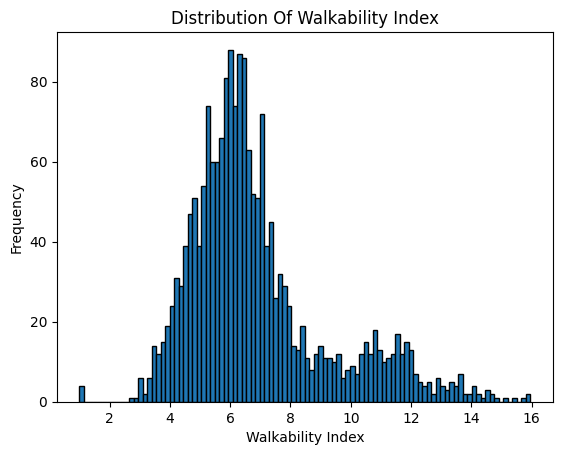

In [49]:
plt.hist(walkDF['NatWalkInd'], bins = 100, edgecolor = 'black')
plt.title("Distribution Of Walkability Index")
plt.xlabel("Walkability Index")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

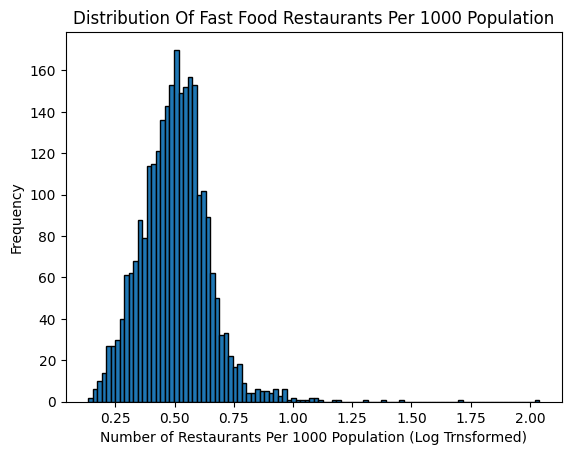

In [53]:
plt.hist(restaurantDF['Log_Transformed_Restaurants'], bins = 100, edgecolor = 'black')
plt.title("Distribution Of Fast Food Restaurants Per 1000 Population")
plt.xlabel("Number of Restaurants Per 1000 Population (Log Trnsformed)")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

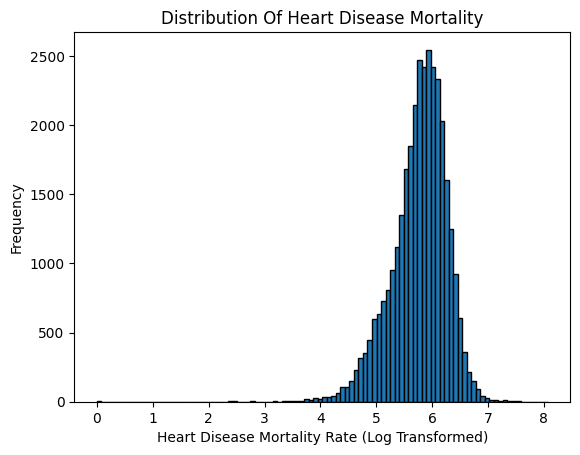

In [48]:
plt.hist(hdDF_cleaned['Log_Mortality'], bins = 100, edgecolor = 'black')
plt.title("Distribution Of Heart Disease Mortality")
plt.xlabel("Heart Disease Mortality Rate (Log Transformed)")
plt.ylabel("Frequency")